# Read simulation data

(continue running from here to change the figures without having to run simulation again)

In [19]:
import pickle

with open("sim_data.pkl", "rb") as f:
    dfs = pickle.load(f)
df_sym, df_5x, df_10x = dfs["df_sym"], dfs["df_5x"], dfs["df_10x"]

# Plot

In [20]:
import os
figures_path = "figures/"
os.makedirs(figures_path, exist_ok=True)

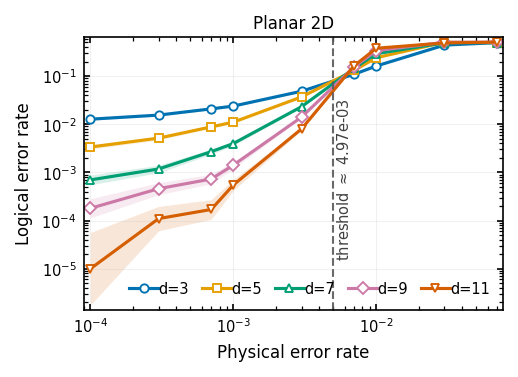

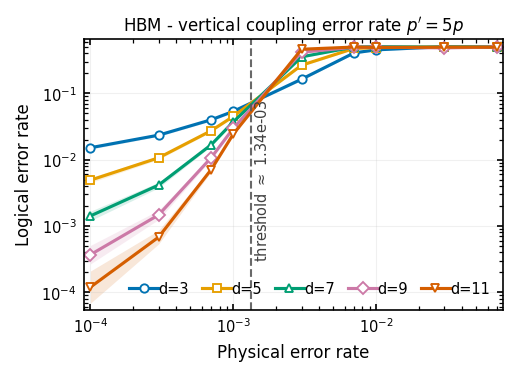

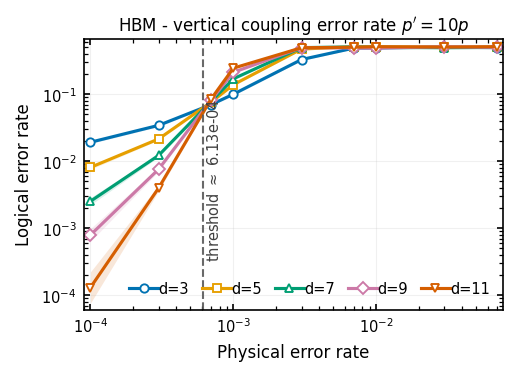

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def wilson_interval(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    p = k / n
    denom = 1.0 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    lo = max(center - half, 1e-12)
    hi = min(center + half, 1.0)
    return lo, hi


def prepare_plot_df(df):
    g = (
        df.groupby(["mode", "distance", "p"], as_index=False)[["shots", "errors"]]
        .sum()
        .sort_values(["mode", "distance", "p"])
    )

    g["ler"] = g["errors"] / g["shots"]
    ci = np.array([wilson_interval(k, n) for k, n in zip(g["errors"], g["shots"])])
    g["ler_lo"] = ci[:, 0]
    g["ler_hi"] = ci[:, 1]
    return g


def set_publication_style():
    plt.rcdefaults()

    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 2.0,
        "ytick.minor.size": 2.0,
        "legend.frameon": False,
    })


def estimate_threshold(sub_df):
    """
    Estimate threshold from crossings between adjacent code-distance curves.
    Works in log-log space and returns the median crossing point.
    """
    distances = sorted(sub_df["distance"].unique())
    crossings = []

    for d1, d2 in zip(distances[:-1], distances[1:]):
        s1 = sub_df[sub_df["distance"] == d1][["p", "ler"]].sort_values("p")
        s2 = sub_df[sub_df["distance"] == d2][["p", "ler"]].sort_values("p")

        merged = pd.merge(s1, s2, on="p", suffixes=("_1", "_2")).dropna()
        if len(merged) < 2:
            continue

        x = np.log10(merged["p"].to_numpy())
        ydiff = np.log10(merged["ler_1"].to_numpy()) - np.log10(merged["ler_2"].to_numpy())

        for i in range(len(x) - 1):
            y0, y1 = ydiff[i], ydiff[i + 1]

            if y0 == 0:
                crossings.append(10 ** x[i])
                continue

            if y0 * y1 < 0:
                # linear interpolation in log p
                xc = x[i] - y0 * (x[i + 1] - x[i]) / (y1 - y0)
                crossings.append(10 ** xc)

    if len(crossings) == 0:
        return None

    return float(np.min(crossings))


def plot_micro_ler_single(df, mode, outname=None):
    set_publication_style()
    plot_df = prepare_plot_df(df)

    title_map = {
        "symmetric":     r"Planar 2D",
        "asymmetric_5x": r"HBM - vertical coupling error rate $p' = 5p$",
        "asymmetric_10x":r"HBM - vertical coupling error rate $p' = 10p$",
    }

    distances = sorted(plot_df["distance"].unique())

    color_map  = {3: "#0072B2", 5: "#E69F00", 7: "#009E73", 9: "#CC79A7", 11: "#D55E00"}
    marker_map = {3: "o",       5: "s",       7: "^",       9: "D",       11: "v"}

    COLUMNWIDTH_PT = 241.14749
    fig_width = COLUMNWIDTH_PT / 72.27

    fig, ax = plt.subplots(figsize=(fig_width, 2.4), constrained_layout=True)

    sub = plot_df[plot_df["mode"] == mode].copy()

    y_positive = sub["ler_lo"][sub["ler_lo"] > 0]
    y_min = max(y_positive.min() * 0.8, 1e-6) if len(y_positive) else 1e-6
    y_max = min(sub["ler_hi"].max() * 1.25, 1.0)

    handles, labels = [], []

    for d in distances:
        s = sub[sub["distance"] == d].sort_values("p")
        if s.empty:
            continue

        line, = ax.plot(
            s["p"], s["ler"],
            label=f"d={d}",
            color=color_map.get(d),
            marker=marker_map.get(d, "o"),
            markerfacecolor="white",
            markeredgewidth=0.9,
        )
        ax.fill_between(
            s["p"], s["ler_lo"], s["ler_hi"],
            color=line.get_color(), alpha=0.15, linewidth=0,
        )
        handles.append(line)
        labels.append(f"d={d}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(sub["p"].min() * 0.9, sub["p"].max() * 1.1)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, which="major", alpha=0.18, linewidth=0.5)
    ax.tick_params(which="both", top=True, right=True)
    ax.set_title(title_map[mode], pad=4)
    ax.set_ylabel("Logical error rate")
    ax.set_xlabel("Physical error rate")

    threshold = estimate_threshold(sub)
    if threshold is not None:
        ax.axvline(threshold, linestyle="--", linewidth=1.0, color="0.35", alpha=0.9)
        ax.text(
            threshold * 1.05,
            y_min * (y_max / y_min) ** 0.18,
            f"threshold $\\approx$ {threshold:.2e}",
            rotation=90, va="bottom", ha="left", color="0.25", fontsize=7,
        )

    ax.legend(
        handles, labels,
        ncol=len(labels),
        loc="lower right",
        columnspacing=0.9,
        handletextpad=0,
    )

    if outname is None:
        outname = os.path.join(figures_path, f"ls_ler_{mode}")
    fig.savefig(f"{outname}.pdf", bbox_inches="tight", pad_inches=0, dpi=600)
    plt.show()


def plot_micro_ler(df, outname):
    for mode in ["symmetric", "asymmetric_5x", "asymmetric_10x"]:
        name = {"symmetric":"planar", "asymmetric_5x":"5x", "asymmetric_10x":"10x"}
        plot_micro_ler_single(df, mode, outname=outname+"_"+name[mode])


df_all = pd.concat([df_sym, df_5x, df_10x], ignore_index=True)
plot_micro_ler(df_all, f"{figures_path}LS_vertical_interconnect")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

P_TARGET = 3e-4
DISTANCES = [3, 5, 7, 9, 11]

import re
import pandas as pd

def parse_routing_file(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("File") or line.startswith("---") or line.startswith("Skipped"):
                continue
            parts = line.split()
            if len(parts) < 7:
                continue
            filename = parts[0]
            N        = int(parts[1])
            MSRD     = float(parts[3])

            # parse mode from filename
            if   "no_hbm"          in filename: mode = "no_hbm"
            elif "ARCH_A"          in filename: mode = "ARCH_A"
            elif "shared_16"       in filename: mode = "ARCH_C_shared_16"
            elif "shared_8"        in filename: mode = "ARCH_C_shared_8"
            elif "shared_4"        in filename: mode = "ARCH_C_shared_4"
            elif "shared_2"        in filename: mode = "ARCH_C_shared_2"
            else: continue

            rows.append(dict(filename=filename, N=N, MSRD=MSRD, mode=mode))

    return pd.DataFrame(rows)

df_routing = parse_routing_file("routing_steps.txt")

def snap_distance(n, distances=DISTANCES):
    d = np.sqrt(n)
    candidates = [x for x in distances if x >= d]
    return min(candidates) if candidates else max(distances)

def lookup_ler(df, d, p):
    row = df[(df["distance"] == d) & np.isclose(df["p"], p)]
    if row.empty:
        return np.nan
    return row["ler"].values[0]

def total_ler(msrd, ler_planar, ler_hbm):
    if np.isclose(msrd, 1.0):
        return ler_planar          # no HBM involved at all
    elif np.isclose(msrd, 2.0):
        return ler_hbm ** 2
    else:
        return (ler_planar ** (msrd - 2)) * (ler_hbm ** 2)

saved total_ler_5x.pdf


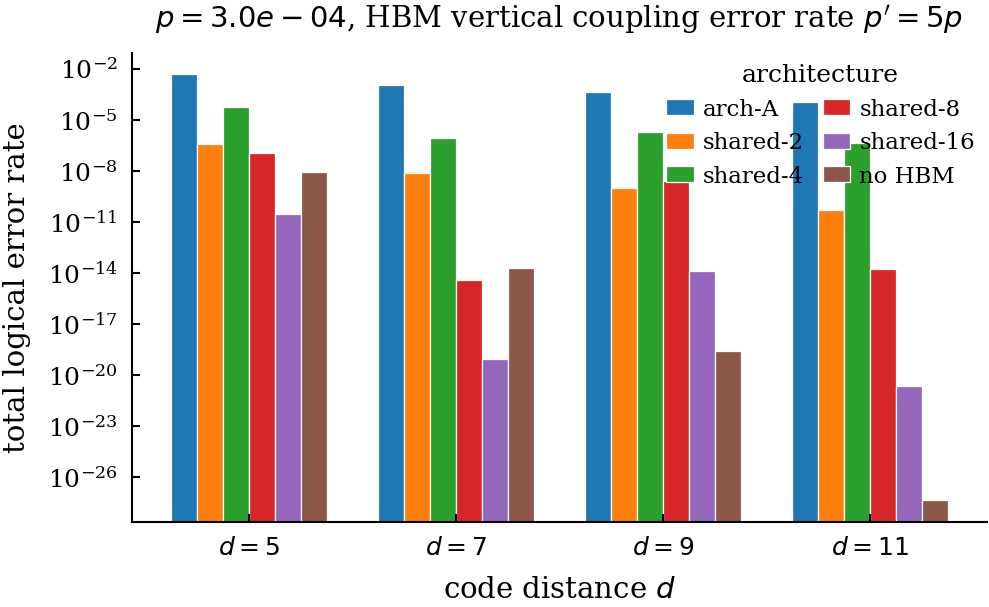

saved total_ler_10x.pdf


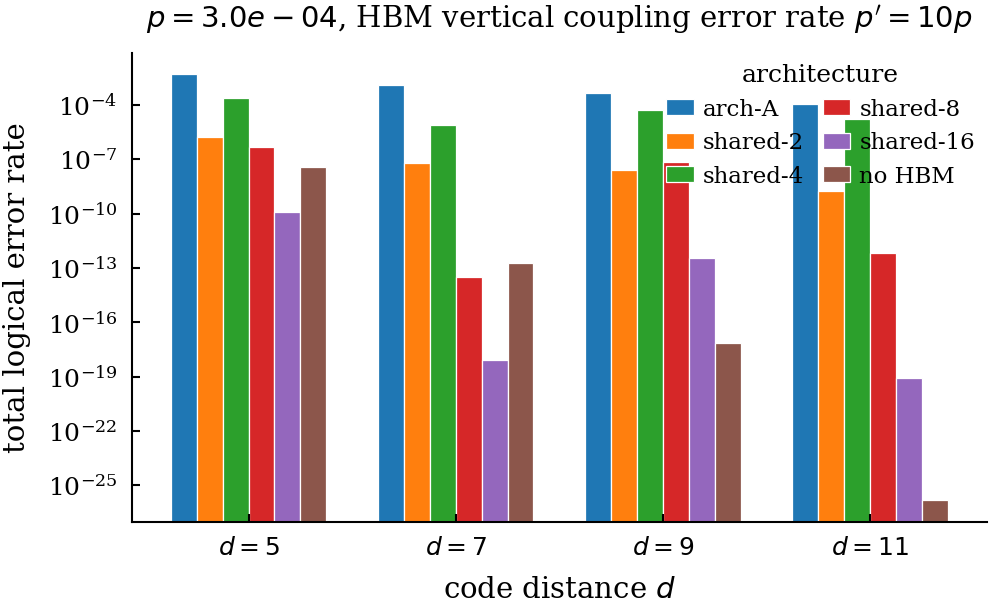

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from collections import defaultdict

COLUMNWIDTH_PT = 241.14749
PT_PER_INCH    = 72.27
COL_IN         = COLUMNWIDTH_PT / PT_PER_INCH          # ~3.34 in
GOLDEN         = (1 + 5**0.5) / 2
FIG_SIZE       = (COL_IN, COL_IN / GOLDEN)             # ~3.34 × 2.06 in

# Use LaTeX fonts to match the paper body
plt.rcParams.update({
    "text.usetex":         False,
    "font.family":         "serif",
    "font.size":           7,
    "axes.titlesize":      7,
    "axes.labelsize":      7,
    "xtick.labelsize":     6,
    "ytick.labelsize":     6,
    "legend.fontsize":     5.5,
    "legend.title_fontsize": 6,
    "axes.linewidth":      0.5,
    "xtick.major.width":   0.5,
    "ytick.major.width":   0.5,
    "xtick.major.size":    2.0,
    "ytick.major.size":    2.0,
    "lines.linewidth":     0.8,
    "patch.linewidth":     0.4,
    "figure.dpi":          300,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
    "savefig.pad_inches":  0.01,
})

MODES = [
    "ARCH_A",
    "ARCH_C_shared_2",
    "ARCH_C_shared_4",
    "ARCH_C_shared_8",
    "ARCH_C_shared_16",
    "no_hbm",
]

MODE_LABELS = {
    "ARCH_A":           r"arch-A",
    "ARCH_C_shared_2":  r"shared-2",
    "ARCH_C_shared_4":  r"shared-4",
    "ARCH_C_shared_8":  r"shared-8",
    "ARCH_C_shared_16": r"shared-16",
    "no_hbm":           r"no HBM",
}


def plot_total_ler(df_hbm, hbm_label, p=P_TARGET, outfile=None):
    ns = sorted(df_routing["N"].unique())
    valid_ns = [n for n in ns if np.sqrt(n) <= max(DISTANCES)]
    if not valid_ns:
        return

    d_to_ns = defaultdict(list)
    for n in valid_ns:
        d_to_ns[snap_distance(n)].append(n)
    ds = sorted(d_to_ns.keys())

    x        = np.arange(len(ds))
    n_modes  = len(MODES)
    width    = 0.75 / n_modes

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    for i, mode in enumerate(MODES):
        lers = []
        for d in ds:
            vals = []
            for n in d_to_ns[d]:
                row = df_routing[(df_routing["N"] == n) & (df_routing["mode"] == mode)]
                if row.empty:
                    continue
                msrd  = row["MSRD"].values[0]
                ler_p = lookup_ler(df_sym, d, p)
                ler_h = lookup_ler(df_hbm, d, p)
                v     = total_ler(msrd, ler_p, ler_h)
                if not np.isnan(v):
                    vals.append(v)
            lers.append(np.mean(vals) if vals else np.nan)

        offset = (i - n_modes / 2 + 0.5) * width
        ax.bar(
            x + offset, lers, width=width,
            label=MODE_LABELS[mode],
            edgecolor="white",
            linewidth=0.3,
        )

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([f"$d={d}$" for d in ds])
    ax.set_xlabel("code distance $d$")
    ax.set_ylabel("total logical error rate")
    # ax.set_title(rf"HBM noise $\times${hbm_label}, $p={p:.0e}$".replace("e-0", r"\times10^{-").replace("e-", r"\times10^{-") + "}")
    ax.set_title(f"$p={p:.1e}$, HBM vertical coupling error rate $p'={hbm_label}p$")

    # clean spine
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
    ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=10))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.tick_params(which="minor", length=1.5, width=0.4)

    ax.legend(
        title="architecture",
        ncol=2,
        frameon=False,
        handlelength=1.2,
        handletextpad=0.4,
        columnspacing=0.8,
        borderpad=0,
    )

    fig.tight_layout(pad=0.3)
    fname = outfile or f"total_ler_{hbm_label}.pdf"
    fig.savefig(figures_path+fname)
    print(f"saved {fname}")
    plt.show()


plot_total_ler(df_5x,  "5",  outfile="total_ler_5x.pdf")
plot_total_ler(df_10x, "10", outfile="total_ler_10x.pdf")